In [209]:
import json
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu, ranksums, rankdata

In [210]:
methods = ["mf", "rnd", "trc", "rl", "line"]
runs = 20
slice_ = 61
# arr = [0,1,2,3,5,6,7,3,10,11,12,13]

coverages = {
    "Random": [],
    "ModelFuzz": [],
    "Trace": [],
    "Line": [],
    "BonuxMaxRL": []
}

for method in methods:
    for i in range(runs):
        with open(f"results/{method}_stats_{i}.json", "r") as f:
            j = json.load(f)
            print(j)
        if method == "mf":
            coverages["ModelFuzz"].append(j["Coverage"])
        elif method == "trc":
            coverages["Trace"].append(j["Coverage"])
        elif method == "line":
            coverages["Line"].append(j["Coverage"])
        elif method == "rl":
            coverages["BonuxMaxRL"].append(j["Coverage"])
        else:
            coverages["Random"].append(j["Coverage"])

cov_data = {
    "Random": [],
    "ModelFuzz": [],
    "Trace": [],
    "Line": [],
    "BonuxMaxRL": []
}

coverages["ModelFuzz"] = np.array(coverages["ModelFuzz"])
coverages["Random"] = np.array(coverages["Random"])
coverages["Trace"] = np.array(coverages["Trace"])
coverages["Line"] = np.array(coverages["Line"])
coverages["BonuxMaxRL"] = np.array(coverages["BonuxMaxRL"])

for key in coverages.keys():
    high = np.zeros(slice_)
    low = np.zeros(slice_)
    avg = np.zeros(slice_)
    for i in range(slice_):
        # print(coverages[key][:i])
        avg[i] = np.mean(coverages[key][:,i])
        high[i] = max(coverages[key][:,i])
        low[i] = min(coverages[key][:,i])

    cov_data[key] = [high, low, avg]

{'Coverage': [0, 537971, 983575, 1401125, 1797568, 2189726, 2558645, 2933363, 3284161, 3624413, 3963187, 4310922, 4641710, 4974505, 5303508, 5623260, 5942439, 6249440, 6556193, 6860665, 7156730, 7452270, 7750051, 8044535, 8329516, 8611117, 8896953, 9180332, 9447782, 9729958, 10021704, 10296514, 10582848, 10861456, 11131851, 11417030, 11683922, 11945468, 12206623, 12479948, 12734816, 12980629, 13231590, 13492570, 13746891, 13999975, 14259577, 14508553, 14753309, 15000794, 15250969, 15513341, 15762275, 16010590, 16262006, 16528562, 16766196, 17002879, 17260160, 17503045, 17740817], 'RandomExecutions': 0, 'MutatedExecutions': 0}
{'Coverage': [0, 521278, 982434, 1405816, 1798090, 2176022, 2551052, 2908238, 3260463, 3610739, 3965403, 4285161, 4612676, 4932258, 5247685, 5566667, 5866676, 6177358, 6483486, 6783313, 7070220, 7385833, 7676643, 7963586, 8239902, 8515981, 8787792, 9066899, 9341129, 9623972, 9903849, 10182053, 10447036, 10708088, 10976960, 11259045, 11532138, 11799205, 12068576, 1

In [215]:
for key in cov_data.keys():
    if key == "ModelFuzz":
        continue
    print(f"ModelFuzz / {key}: {(cov_data['ModelFuzz'][2][-1] / cov_data[key][2][-1])}")

ModelFuzz / Random: 1.1604741311411084
ModelFuzz / Trace: 1.2313672242975566
ModelFuzz / Line: 1.1929143287714814
ModelFuzz / BonuxMaxRL: 182.95942575936854


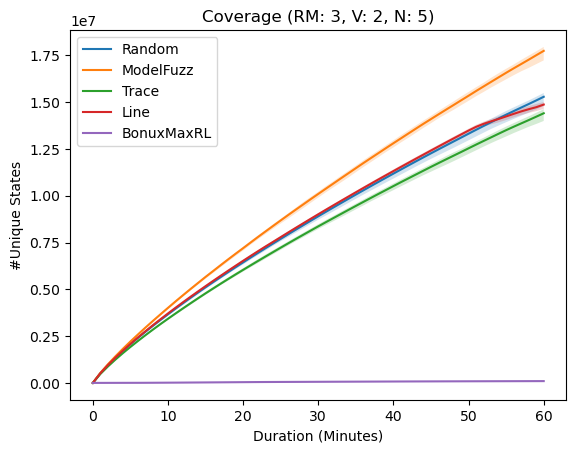

In [ ]:
fig, ax = plt.subplots()

colors = {
    "Random": "tab:blue",
    "ModelFuzz": "tab:orange",
    "Trace": "tab:green",
    "Line": "tab:red",
    "BonuxMaxRL": "tab:purple"
}

for (b, bands) in cov_data.items():
    ax.plot(np.arange(len(bands[0])), bands[2], label=b, color=colors[b])
    ax.fill_between(np.arange(len(bands[0])), bands[0], bands[1], alpha=0.2)

ax.set_xlabel('Duration (Minutes)')
ax.set_ylabel('#Unique States')
ax.set_title("Coverage (RM: 3, V: 2, N: 5)")
ax.legend()

# plt.show()
plt.savefig("2pc_coverage.pdf", format="pdf", bbox_inches="tight")

In [216]:

for method in coverages.keys():
    if method == "ModelFuzz":
        continue
    else:
        stat, p = mannwhitneyu(coverages["ModelFuzz"][:,-1], coverages[method][:,-1])
    print(f'P-value for M-W u test with ModelFuzz and {method}: {p}')

P-value for M-W u test with ModelFuzz and Random: 6.795615128173357e-08
P-value for M-W u test with ModelFuzz and Trace: 6.795615128173357e-08
P-value for M-W u test with ModelFuzz and Line: 6.795615128173357e-08
P-value for M-W u test with ModelFuzz and BonuxMaxRL: 6.795615128173357e-08


In [222]:
for key in cov_data.keys():
    print(f"Mean coverage for {key}: {cov_data[key][2][-1]}")

Mean coverage for Random: 15289828.85
Mean coverage for ModelFuzz: 17743450.85
Mean coverage for Trace: 14409552.65
Mean coverage for Line: 14874036.15
Mean coverage for BonuxMaxRL: 96980.25
